# 🧹 02 — DATA CLEANING & PREPARATION
### QM640 Capstone | Kunal Mishra

---

## What this notebook does

Takes the raw CSV files from notebook 01 and produces clean, aligned DataFrames.
Also applies the **Global Clock Protocol** — the most important data engineering rule in this project.

### Problems we fix in this notebook:
| Problem | What it means | How we fix it |
|---|---|---|
| Missing dates | NIFTY and S&P 500 have different holidays | Align on a shared trading calendar |
| Missing values | Some macro data has gaps on holidays | Forward-fill (carry last known value forward) |
| Look-ahead bias | NIFTY closes before S&P 500 publishes | Global Clock Protocol: use t-1 US values |
| Date format issues | Different sources format dates differently | Standardise all dates to YYYY-MM-DD |

### The Global Clock Protocol (most important concept here)
> NIFTY 50 closes at **10:00 UTC**.  
> S&P 500 closes at **20:00 UTC** — 10 hours later.  
> Fear & Greed Index is also published after US market close.
>
> This means: when the Indian market closes on Monday, the US market hasn't closed yet.  
> **If we used the same-day US data for NIFTY predictions, that's cheating** (look-ahead bias).  
> So for NIFTY models, we always use the **prior day's (t-1)** S&P 500 and Fear & Greed values.

---
**Reads from:** `data/raw/`  
**Writes to:** `data/clean/`

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Mount Drive and load config
# ─────────────────────────────────────────────────────────────────────────────

from google.colab import drive
drive.mount('/content/drive')

import json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
warnings.filterwarnings('ignore')

with open('/content/drive/MyDrive/CapstoneDA/config.json') as f:
    CFG = json.load(f)

RAW   = CFG['PATHS']['raw']
CLEAN = CFG['PATHS']['clean']
PLOTS = CFG['PATHS']['plots']
SEED  = CFG['SEED']
np.random.seed(SEED)

print('✅ Google Drive mounted.')
print('✅ Config loaded.')
print(f'   Reading from : {RAW}/')
print(f'   Writing to   : {CLEAN}/')

Mounted at /content/drive
✅ Google Drive mounted.
✅ Config loaded.
   Reading from : /content/drive/MyDrive/CapstoneDA/data/raw/
   Writing to   : /content/drive/MyDrive/CapstoneDA/data/clean/


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Load all raw files
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Reads all 6 CSV files we saved in notebook 01.
#   Parses date columns correctly so Python understands them as dates.
# ─────────────────────────────────────────────────────────────────────────────

print('Loading raw data files from Google Drive...')
print()

def load_csv(path, label):
    """Load a CSV file, parse the Date column, and report basic info."""
    df = pd.read_csv(path, index_col='Date', parse_dates=['Date'])
    df.index = df.index.tz_localize(None)   # remove timezone if present
    print(f'  ✅  {label:30}  {len(df):>5} rows  |  {df.index[0].date()} → {df.index[-1].date()}')
    return df

sp500_raw = load_csv(f'{RAW}/sp500_ohlcv.csv', 'S&P 500 OHLCV')
nifty_raw = load_csv(f'{RAW}/nifty_ohlcv.csv', 'NIFTY 50 OHLCV')
macro_raw = load_csv(f'{RAW}/macro_fred.csv',   'Macro (FRED)')
fg_raw    = load_csv(f'{RAW}/fear_greed.csv',   'Fear & Greed')
svi_sp500 = load_csv(f'{RAW}/svi_sp500.csv',    'SVI S&P 500 (weekly)')
svi_nifty = load_csv(f'{RAW}/svi_nifty.csv',    'SVI NIFTY 50 (weekly)')

print()
print('All files loaded successfully.')

Loading raw data files from Google Drive...

  ✅  S&P 500 OHLCV                    2513 rows  |  2016-01-04 → 2025-12-30
  ✅  NIFTY 50 OHLCV                   2463 rows  |  2016-01-04 → 2025-12-30
  ✅  Macro (FRED)                     2608 rows  |  2016-01-04 → 2025-12-31
  ✅  Fear & Greed                     2609 rows  |  2016-01-01 → 2025-12-31
  ✅  SVI S&P 500 (weekly)              522 rows  |  2016-01-04 → 2025-12-29
  ✅  SVI NIFTY 50 (weekly)             522 rows  |  2016-01-04 → 2025-12-29

All files loaded successfully.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Check missing values in each dataset
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Before cleaning, we document exactly what is missing and where.
#   This is standard practice — you always inspect before you clean.
# ─────────────────────────────────────────────────────────────────────────────

def missing_report(df, label):
    """Print a summary of missing values in a DataFrame."""
    total_cells = df.shape[0] * df.shape[1]
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f'  {label:30}  ✅  No missing values')
    else:
        print(f'  {label:30}  ⚠️   Missing values:')
        for col, n in missing.items():
            pct = n / len(df) * 100
            print(f'       {col:20} {n:4} rows  ({pct:.1f}%)')

print('Missing value check:')
print()
missing_report(sp500_raw, 'S&P 500 OHLCV')
missing_report(nifty_raw, 'NIFTY 50 OHLCV')
missing_report(macro_raw, 'Macro (FRED)')
missing_report(fg_raw,    'Fear & Greed')
missing_report(svi_sp500, 'SVI S&P 500')
missing_report(svi_nifty, 'SVI NIFTY 50')

Missing value check:

  S&P 500 OHLCV                   ✅  No missing values
  NIFTY 50 OHLCV                  ✅  No missing values
  Macro (FRED)                    ✅  No missing values
  Fear & Greed                    ✅  No missing values
  SVI S&P 500                     ✅  No missing values
  SVI NIFTY 50                    ✅  No missing values


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Clean Fear & Greed: add ordinal zone encoding
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   The raw Fear & Greed file has a text column (e.g. 'Extreme Fear').
#   Machine learning models cannot work with text directly.
#   We convert it to a number (1 to 5) using ordinal encoding.
#
#   Ordinal encoding means the order matters:
#     Extreme Fear (1) < Fear (2) < Neutral (3) < Greed (4) < Extreme Greed (5)
#
#   We also compute FG_Delta = the day-over-day change in the index score.
#   A large positive FG_Delta means sentiment jumped up quickly (greed accelerating).
#   A large negative FG_Delta means sentiment dropped quickly (fear accelerating).
# ─────────────────────────────────────────────────────────────────────────────

# Step 1: Map text zones to numbers
ZONE_MAP = {
    'Extreme Fear' : 1,
    'Fear'         : 2,
    'Neutral'      : 3,
    'Greed'        : 4,
    'Extreme Greed': 5
}

fg_clean = fg_raw.copy()
fg_clean['FG_Zone']  = fg_clean['FG_Classification'].map(ZONE_MAP).fillna(3).astype(int)
fg_clean['FG_Delta'] = fg_clean['FG_Index'].diff()   # today minus yesterday

# Step 2: Fill weekends and holidays by carrying the last known value forward
# (Fear & Greed only publishes on trading days)
fg_clean = fg_clean.asfreq('B').ffill()   # 'B' = business day frequency
fg_clean.dropna(subset=['FG_Index'], inplace=True)

# Step 3: Drop the text column (no longer needed)
fg_clean = fg_clean.drop(columns=['FG_Classification'], errors='ignore')

print('Fear & Greed cleaned:')
print(f'  Original rows: {len(fg_raw)}')
print(f'  Clean rows   : {len(fg_clean)}')
print()
print('Column meanings:')
print('  FG_Index = raw score (0-100)')
print('  FG_Zone  = encoded zone (1=Extreme Fear, 5=Extreme Greed)')
print('  FG_Delta = day-over-day change in score')
print()
fg_clean.tail()

Fear & Greed cleaned:
  Original rows: 2609
  Clean rows   : 2609

Column meanings:
  FG_Index = raw score (0-100)
  FG_Zone  = encoded zone (1=Extreme Fear, 5=Extreme Greed)
  FG_Delta = day-over-day change in score



,FG_Index,FG_Zone,FG_Delta
Date,,,
2025-12-25,100,5,0.0
2025-12-26,100,5,0.0
2025-12-29,100,5,0.0
2025-12-30,100,5,0.0
2025-12-31,100,5,0.0


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Clean macro data: forward-fill gaps
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   FRED data has gaps for weekends and US bank holidays.
#   Forward-filling means: if Monday's value is missing,
#   use Friday's value (carry it forward over the weekend).
#   This is standard practice for daily financial data.
# ─────────────────────────────────────────────────────────────────────────────

macro_clean = macro_raw.copy()

# Align to business-day calendar and forward-fill gaps
macro_clean = macro_clean.asfreq('B').ffill()

# Final safety: drop any remaining rows with all-NaN (very rare)
macro_clean.dropna(how='all', inplace=True)

print('Macro data cleaned:')
print(f'  Original rows : {len(macro_raw)}')
print(f'  After cleaning: {len(macro_clean)}')
print()
print('Current data ranges:')
for col in macro_clean.columns:
    series  = macro_clean[col].dropna()
    print(f'  {col:8}  min={series.min():.2f}  max={series.max():.2f}  missing={macro_clean[col].isnull().sum()}')

Macro data cleaned:
  Original rows : 2608
  After cleaning: 2608

Current data ranges:
  VIX       min=9.14  max=82.69  missing=0
  US10Y     min=0.52  max=4.98  missing=0
  US2Y      min=0.09  max=5.19  missing=0
  BRENT     min=9.12  max=133.18  missing=0
  USDINR    min=63.38  max=91.03  missing=0
  GOLD      min=1073.90  max=4529.10  missing=0


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Clean SVI: expand from weekly to daily
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Google Trends gives us ONE value per week (every Monday).
#   Our market data is daily. We need to bridge this gap.
#   Method: forward-fill — Monday's search value applies
#   to Tuesday, Wednesday, Thursday, Friday of that week.
#   This is valid because search trends change gradually over days.
#
# We also cap forward-fill at 2 days max over holidays
# (if a market is closed for 3+ days, we prefer NaN over stale data).
# ─────────────────────────────────────────────────────────────────────────────

def expand_weekly_svi(svi_weekly, sp500_index, nifty_index):
    """
    Expand weekly SVI to daily using forward-fill.
    Returns (sp500_daily_svi, nifty_daily_svi)
    """
    # Reindex to US trading days (S&P 500 calendar)
    sp500_daily = svi_weekly.reindex(sp500_index, method='ffill', limit=4)

    # Reindex to Indian trading days (NIFTY calendar)
    nifty_daily = svi_weekly.reindex(nifty_index, method='ffill', limit=4)

    return sp500_daily, nifty_daily

svi_sp500_daily, _ = expand_weekly_svi(svi_sp500, sp500_raw.index, nifty_raw.index)
_, svi_nifty_daily = expand_weekly_svi(svi_nifty, sp500_raw.index, nifty_raw.index)

print('SVI expanded from weekly to daily:')
print(f'  SVI S&P 500: {len(svi_sp500)} weekly obs → {len(svi_sp500_daily)} daily obs')
print(f'  SVI NIFTY   : {len(svi_nifty)} weekly obs → {len(svi_nifty_daily)} daily obs')
print()
print('Example: weekly value carried forward across the trading week:')
# Show one week to illustrate
sample = svi_sp500_daily.iloc[:7]
if not sample.empty:
    print(sample.iloc[:, 0:2].to_string())

SVI expanded from weekly to daily:
  SVI S&P 500: 522 weekly obs → 2513 daily obs
  SVI NIFTY   : 522 weekly obs → 2463 daily obs

Example: weekly value carried forward across the trading week:
            stock market  S&P 500
Date                             
2016-01-04            58       44
2016-01-05            58       44
2016-01-06            58       44
2016-01-07            58       44
2016-01-08            58       44
2016-01-11            71       77
2016-01-12            71       77


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Apply the Global Clock Protocol
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Creates t-1 (prior day) versions of US-published signals for NIFTY models.
#
# Why this matters — step by step:
#   Monday 9:15 AM India time → NIFTY 50 opens and closes by 3:30 PM India time
#   That is 10:00 UTC. The model makes a prediction based on available info.
#   Monday 9:30 AM New York → S&P 500 opens (14:30 UTC), closes at 20:00 UTC
#   Monday evening → Fear & Greed Index is published
#
#   So Monday's S&P 500 close and Monday's Fear & Greed score are NOT available
#   when we are predicting NIFTY's direction on Monday.
#   We can only use FRIDAY's values (t-1 = prior trading day).
#
#   Using same-day US data would be 'cheating' because that information
#   did not exist when the NIFTY market was trading.
#   This is called look-ahead bias and it makes model results unrealistically good.
# ─────────────────────────────────────────────────────────────────────────────

print('Applying Global Clock Protocol...')
print()
print('  Rule: For NIFTY 50 features,')
print('        SP500_t1_Ret = S&P 500 return from PREVIOUS trading day')
print('        FG_t1_Index  = Fear & Greed score from PREVIOUS trading day')
print()

# Compute S&P 500 daily log return (we shift by 1 to get the prior day value)
# Log return formula: ln(today's close / yesterday's close)
# Log returns are used instead of raw prices because they are stationary and additive
sp500_log_ret = np.log(sp500_raw['close'] / sp500_raw['close'].shift(1))

# t-1 means shift by 1 day into the past
# So the value at index 'Monday' is actually 'Friday's' return
sp500_t1_ret  = sp500_log_ret.shift(1)
sp500_t1_ret.name = 'SP500_t1_Ret'

# Same for Fear & Greed — use yesterday's score
fg_t1_index = fg_clean['FG_Index'].shift(1)
fg_t1_index.name = 'FG_t1_Index'

print('  ✅  SP500_t1_Ret created (1-day lag on S&P 500 log return)')
print('  ✅  FG_t1_Index  created (1-day lag on Fear & Greed score)')
print()
print('  These features are ONLY added to NIFTY 50 models, not S&P 500 models.')
print()

# Show that the lag is correct
check = pd.DataFrame({
    'SP500_Same_Day_Ret': sp500_log_ret,
    'SP500_t1_Ret (lagged)': sp500_t1_ret
}).dropna().iloc[:5]
print('  Verification (t-1 column should be 1 day behind):')
print(check.to_string())

Applying Global Clock Protocol...

  Rule: For NIFTY 50 features,
        SP500_t1_Ret = S&P 500 return from PREVIOUS trading day
        FG_t1_Index  = Fear & Greed score from PREVIOUS trading day

  ✅  SP500_t1_Ret created (1-day lag on S&P 500 log return)
  ✅  FG_t1_Index  created (1-day lag on Fear & Greed score)

  These features are ONLY added to NIFTY 50 models, not S&P 500 models.

  Verification (t-1 column should be 1 day behind):
            SP500_Same_Day_Ret  SP500_t1_Ret (lagged)
Date                                                 
2016-01-06           -0.013202               0.002010
2016-01-07           -0.023986              -0.013202
2016-01-08           -0.010898              -0.023986
2016-01-11            0.000853              -0.010898
2016-01-12            0.007773               0.000853


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Save all cleaned datasets to Google Drive
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Saves the cleaned versions of every dataset.
#   Also saves the two lag features (SP500_t1_Ret and FG_t1_Index)
#   as a separate file that notebook 03 will attach to NIFTY features.
# ─────────────────────────────────────────────────────────────────────────────

# Align all datasets to business-day calendar
sp500_clean = sp500_raw.copy()
nifty_clean = nifty_raw.copy()

# Save market OHLCV (no changes to the price data itself, just confirming format)
sp500_clean.to_csv(f'{CLEAN}/sp500_clean.csv')
nifty_clean.to_csv(f'{CLEAN}/nifty_clean.csv')

# Save cleaned macro
macro_clean.to_csv(f'{CLEAN}/macro_clean.csv')

# Save cleaned Fear & Greed
fg_clean.to_csv(f'{CLEAN}/fear_greed_clean.csv')

# Save daily SVI (expanded from weekly)
svi_sp500_daily.to_csv(f'{CLEAN}/svi_sp500_daily.csv')
svi_nifty_daily.to_csv(f'{CLEAN}/svi_nifty_daily.csv')

# Save the Global Clock Protocol lag features (NIFTY-only)
nifty_lag_features = pd.DataFrame({
    'SP500_t1_Ret': sp500_t1_ret,
    'FG_t1_Index' : fg_t1_index
})
nifty_lag_features.index.name = 'Date'
nifty_lag_features.to_csv(f'{CLEAN}/nifty_lag_features.csv')

print('Files saved to Google Drive:')
print()
files = [
    ('sp500_clean.csv',        sp500_clean,      'S&P 500 price data'),
    ('nifty_clean.csv',        nifty_clean,      'NIFTY 50 price data'),
    ('macro_clean.csv',        macro_clean,      'Macro indicators (gap-filled)'),
    ('fear_greed_clean.csv',   fg_clean,         'Fear & Greed (with FG_Zone, FG_Delta)'),
    ('svi_sp500_daily.csv',    svi_sp500_daily,  'SVI for S&P 500 (daily, expanded)'),
    ('svi_nifty_daily.csv',    svi_nifty_daily,  'SVI for NIFTY 50 (daily, expanded)'),
    ('nifty_lag_features.csv', nifty_lag_features, 'Lag features for NIFTY (Clock Protocol)'),
]

for filename, df, description in files:
    print(f'  ✅  {filename:30}  {len(df):>5} rows  — {description}')

Files saved to Google Drive:

  ✅  sp500_clean.csv                  2513 rows  — S&P 500 price data
  ✅  nifty_clean.csv                  2463 rows  — NIFTY 50 price data
  ✅  macro_clean.csv                  2608 rows  — Macro indicators (gap-filled)
  ✅  fear_greed_clean.csv             2609 rows  — Fear & Greed (with FG_Zone, FG_Delta)
  ✅  svi_sp500_daily.csv              2513 rows  — SVI for S&P 500 (daily, expanded)
  ✅  svi_nifty_daily.csv              2463 rows  — SVI for NIFTY 50 (daily, expanded)
  ✅  nifty_lag_features.csv           2609 rows  — Lag features for NIFTY (Clock Protocol)


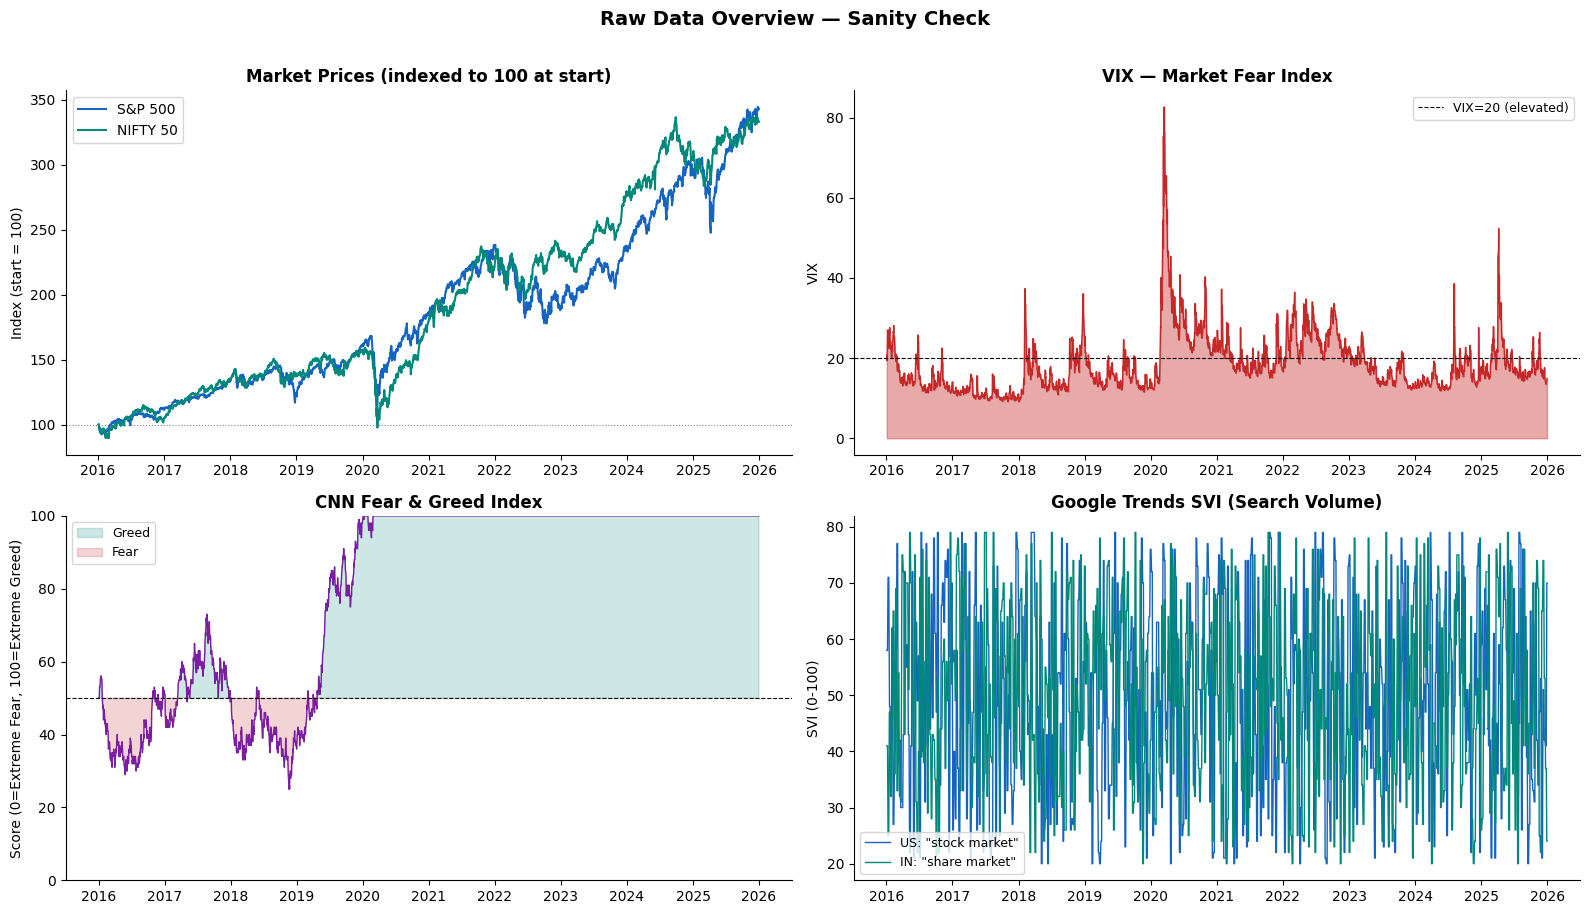

✅ Chart saved to data/plots/02_data_overview.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Visualise the data we have (4 charts)
# ─────────────────────────────────────────────────────────────────────────────
# What this does:
#   Plots the key raw signals so we can do a quick sanity check.
#   If the lines look right (stock prices go up over time, VIX spikes in 2020, etc.)
#   then the data was downloaded correctly.
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('Raw Data Overview — Sanity Check', fontsize=14, fontweight='bold', y=1.01)

# Chart 1: S&P 500 vs NIFTY 50 closing prices (normalised to 100 at start)
ax = axes[0, 0]
sp_norm = (sp500_clean['close'] / sp500_clean['close'].iloc[0]) * 100
ni_norm = (nifty_clean['close'] / nifty_clean['close'].iloc[0]) * 100
ax.plot(sp_norm.index, sp_norm, color='#1565C0', linewidth=1.5, label='S&P 500')
ax.plot(ni_norm.index, ni_norm, color='#00897B', linewidth=1.5, label='NIFTY 50')
ax.set_title('Market Prices (indexed to 100 at start)', fontweight='bold')
ax.set_ylabel('Index (start = 100)')
ax.legend()
ax.axhline(100, color='grey', linestyle=':', linewidth=0.8)

# Chart 2: VIX (fear index)
ax = axes[0, 1]
if 'VIX' in macro_clean.columns:
    ax.fill_between(macro_clean.index, macro_clean['VIX'], alpha=0.4, color='#C62828')
    ax.plot(macro_clean.index, macro_clean['VIX'], color='#C62828', linewidth=1)
    ax.axhline(20, color='black', linestyle='--', linewidth=0.8, label='VIX=20 (elevated)')
    ax.set_title('VIX — Market Fear Index', fontweight='bold')
    ax.set_ylabel('VIX')
    ax.legend(fontsize=9)

# Chart 3: Fear & Greed Index
ax = axes[1, 0]
if 'FG_Index' in fg_clean.columns:
    ax.plot(fg_clean.index, fg_clean['FG_Index'], color='#7B1FA2', linewidth=1)
    ax.fill_between(fg_clean.index, fg_clean['FG_Index'], 50, alpha=0.2,
                    where=fg_clean['FG_Index'] >= 50, color='#00897B', label='Greed')
    ax.fill_between(fg_clean.index, fg_clean['FG_Index'], 50, alpha=0.2,
                    where=fg_clean['FG_Index'] < 50,  color='#C62828', label='Fear')
    ax.axhline(50, color='black', linestyle='--', linewidth=0.8)
    ax.set_ylim(0, 100)
    ax.set_title('CNN Fear & Greed Index', fontweight='bold')
    ax.set_ylabel('Score (0=Extreme Fear, 100=Extreme Greed)')
    ax.legend(fontsize=9)

# Chart 4: Google Trends SVI (first keyword of each market)
ax = axes[1, 1]
first_sp = svi_sp500_daily.columns[0] if not svi_sp500_daily.empty else None
first_ni = svi_nifty_daily.columns[0] if not svi_nifty_daily.empty else None
if first_sp:
    ax.plot(svi_sp500_daily.index, svi_sp500_daily[first_sp],
            color='#1565C0', linewidth=1, label=f'US: "{first_sp}"')
if first_ni:
    ax.plot(svi_nifty_daily.index, svi_nifty_daily[first_ni],
            color='#00897B', linewidth=1, label=f'IN: "{first_ni}"')
ax.set_title('Google Trends SVI (Search Volume)', fontweight='bold')
ax.set_ylabel('SVI (0-100)')
ax.legend(fontsize=9)

for ax_row in axes:
    for ax in ax_row:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PLOTS}/02_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved to data/plots/02_data_overview.png')

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Final summary
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 55)
print('  DATA CLEANING COMPLETE')
print('=' * 55)
print()
print('What was done:')
print('  ✅  Loaded 6 raw data files from notebook 01')
print('  ✅  Filled missing values (forward-fill method)')
print('  ✅  Encoded Fear & Greed zones (text → numbers 1-5)')
print('  ✅  Computed FG_Delta (day-over-day change in sentiment)')
print('  ✅  Expanded SVI from weekly to daily frequency')
print('  ✅  Applied Global Clock Protocol (SP500_t1_Ret, FG_t1_Index)')
print('  ✅  Saved 7 clean files to data/clean/')
print('  ✅  Saved 1 overview chart to data/plots/')
print()
print('─' * 55)
print('  Next step → open  03_FEATURE_ENGINEERING.ipynb')
print('─' * 55)

  DATA CLEANING COMPLETE

What was done:
  ✅  Loaded 6 raw data files from notebook 01
  ✅  Filled missing values (forward-fill method)
  ✅  Encoded Fear & Greed zones (text → numbers 1-5)
  ✅  Computed FG_Delta (day-over-day change in sentiment)
  ✅  Expanded SVI from weekly to daily frequency
  ✅  Applied Global Clock Protocol (SP500_t1_Ret, FG_t1_Index)
  ✅  Saved 7 clean files to data/clean/
  ✅  Saved 1 overview chart to data/plots/

───────────────────────────────────────────────────────
  Next step → open  03_FEATURE_ENGINEERING.ipynb
───────────────────────────────────────────────────────
